In [161]:
import pandas as pd
import numpy as np
import seaborn as sns

In [162]:
live = pd.read_csv("../data/samples/ollama/live_metrics.csv",)
verbose = pd.read_csv("../data/samples/ollama/verbose_statements.csv",)
initial = pd.read_csv("../data/samples/ollama/initial_statement.csv",)

In [163]:
response_time = verbose['total_duration'].tolist()
eval_rate = verbose['eval_rate'].tolist()
response_time = response_time[:-1]
reset_iters = live[live['Iter'] == 1].index.tolist()
eval_rates = [np.float64(evals[:-9]) for evals in eval_rate]

In [164]:
live_data = live.copy()
live_data = live_data.dropna()
live_data = live.drop(columns='Prompt')
corr_matrix = live_data.corr()
corr_matrix

,GPU Util,Power Draw,GPU Temp,GPU Clock,Mem Clock,Mem Used,Mem Util,Time,Time Delta,Iter
GPU Util,1.000000,0.593940,0.850593,0.566516,NaN,0.558457,0.984606,0.229820,0.229794,0.193269
Power Draw,0.593940,1.000000,0.632645,0.940428,NaN,0.926230,0.582237,0.134023,0.133995,0.169276
GPU Temp,0.850593,0.632645,1.000000,0.648092,NaN,0.638945,0.834220,0.447643,0.447632,0.070172
GPU Clock,0.566516,0.940428,0.648092,1.000000,NaN,0.984983,0.561601,0.204384,0.204359,0.070822
Mem Clock,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mem Used,0.558457,0.926230,0.638945,0.984983,NaN,1.000000,0.554592,0.202572,0.202557,0.068923
Mem Util,0.984606,0.582237,0.834220,0.561601,NaN,0.554592,1.000000,0.265172,0.265147,0.119363
Time,0.229820,0.134023,0.447643,0.204384,NaN,0.202572,0.265172,1.000000,0.999995,-0.493058
Time Delta,0.229794,0.133995,0.447632,0.204359,NaN,0.202557,0.265147,0.999995,1.000000,-0.493056
Iter,0.193269,0.169276,0.070172,0.070822,NaN,0.068923,0.119363,-0.493058,-0.493056,1.000000


In [165]:
live_data = live_data.drop(columns=['Mem Clock'])
corr_matrix = live_data.iloc[:, 1:].corr()

In [166]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
tri_up = corr_matrix.mask(mask)
to_drop = [col for col in tri_up.columns if any(tri_up[col] > 0.9)]

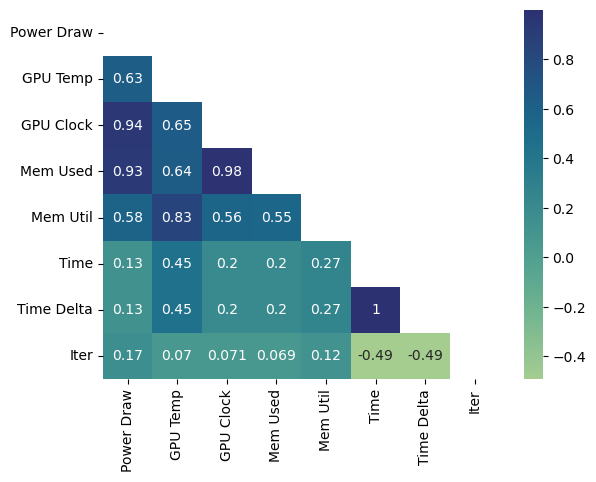

In [167]:
heatmap = sns.heatmap(tri_up, cmap='crest', annot=True)

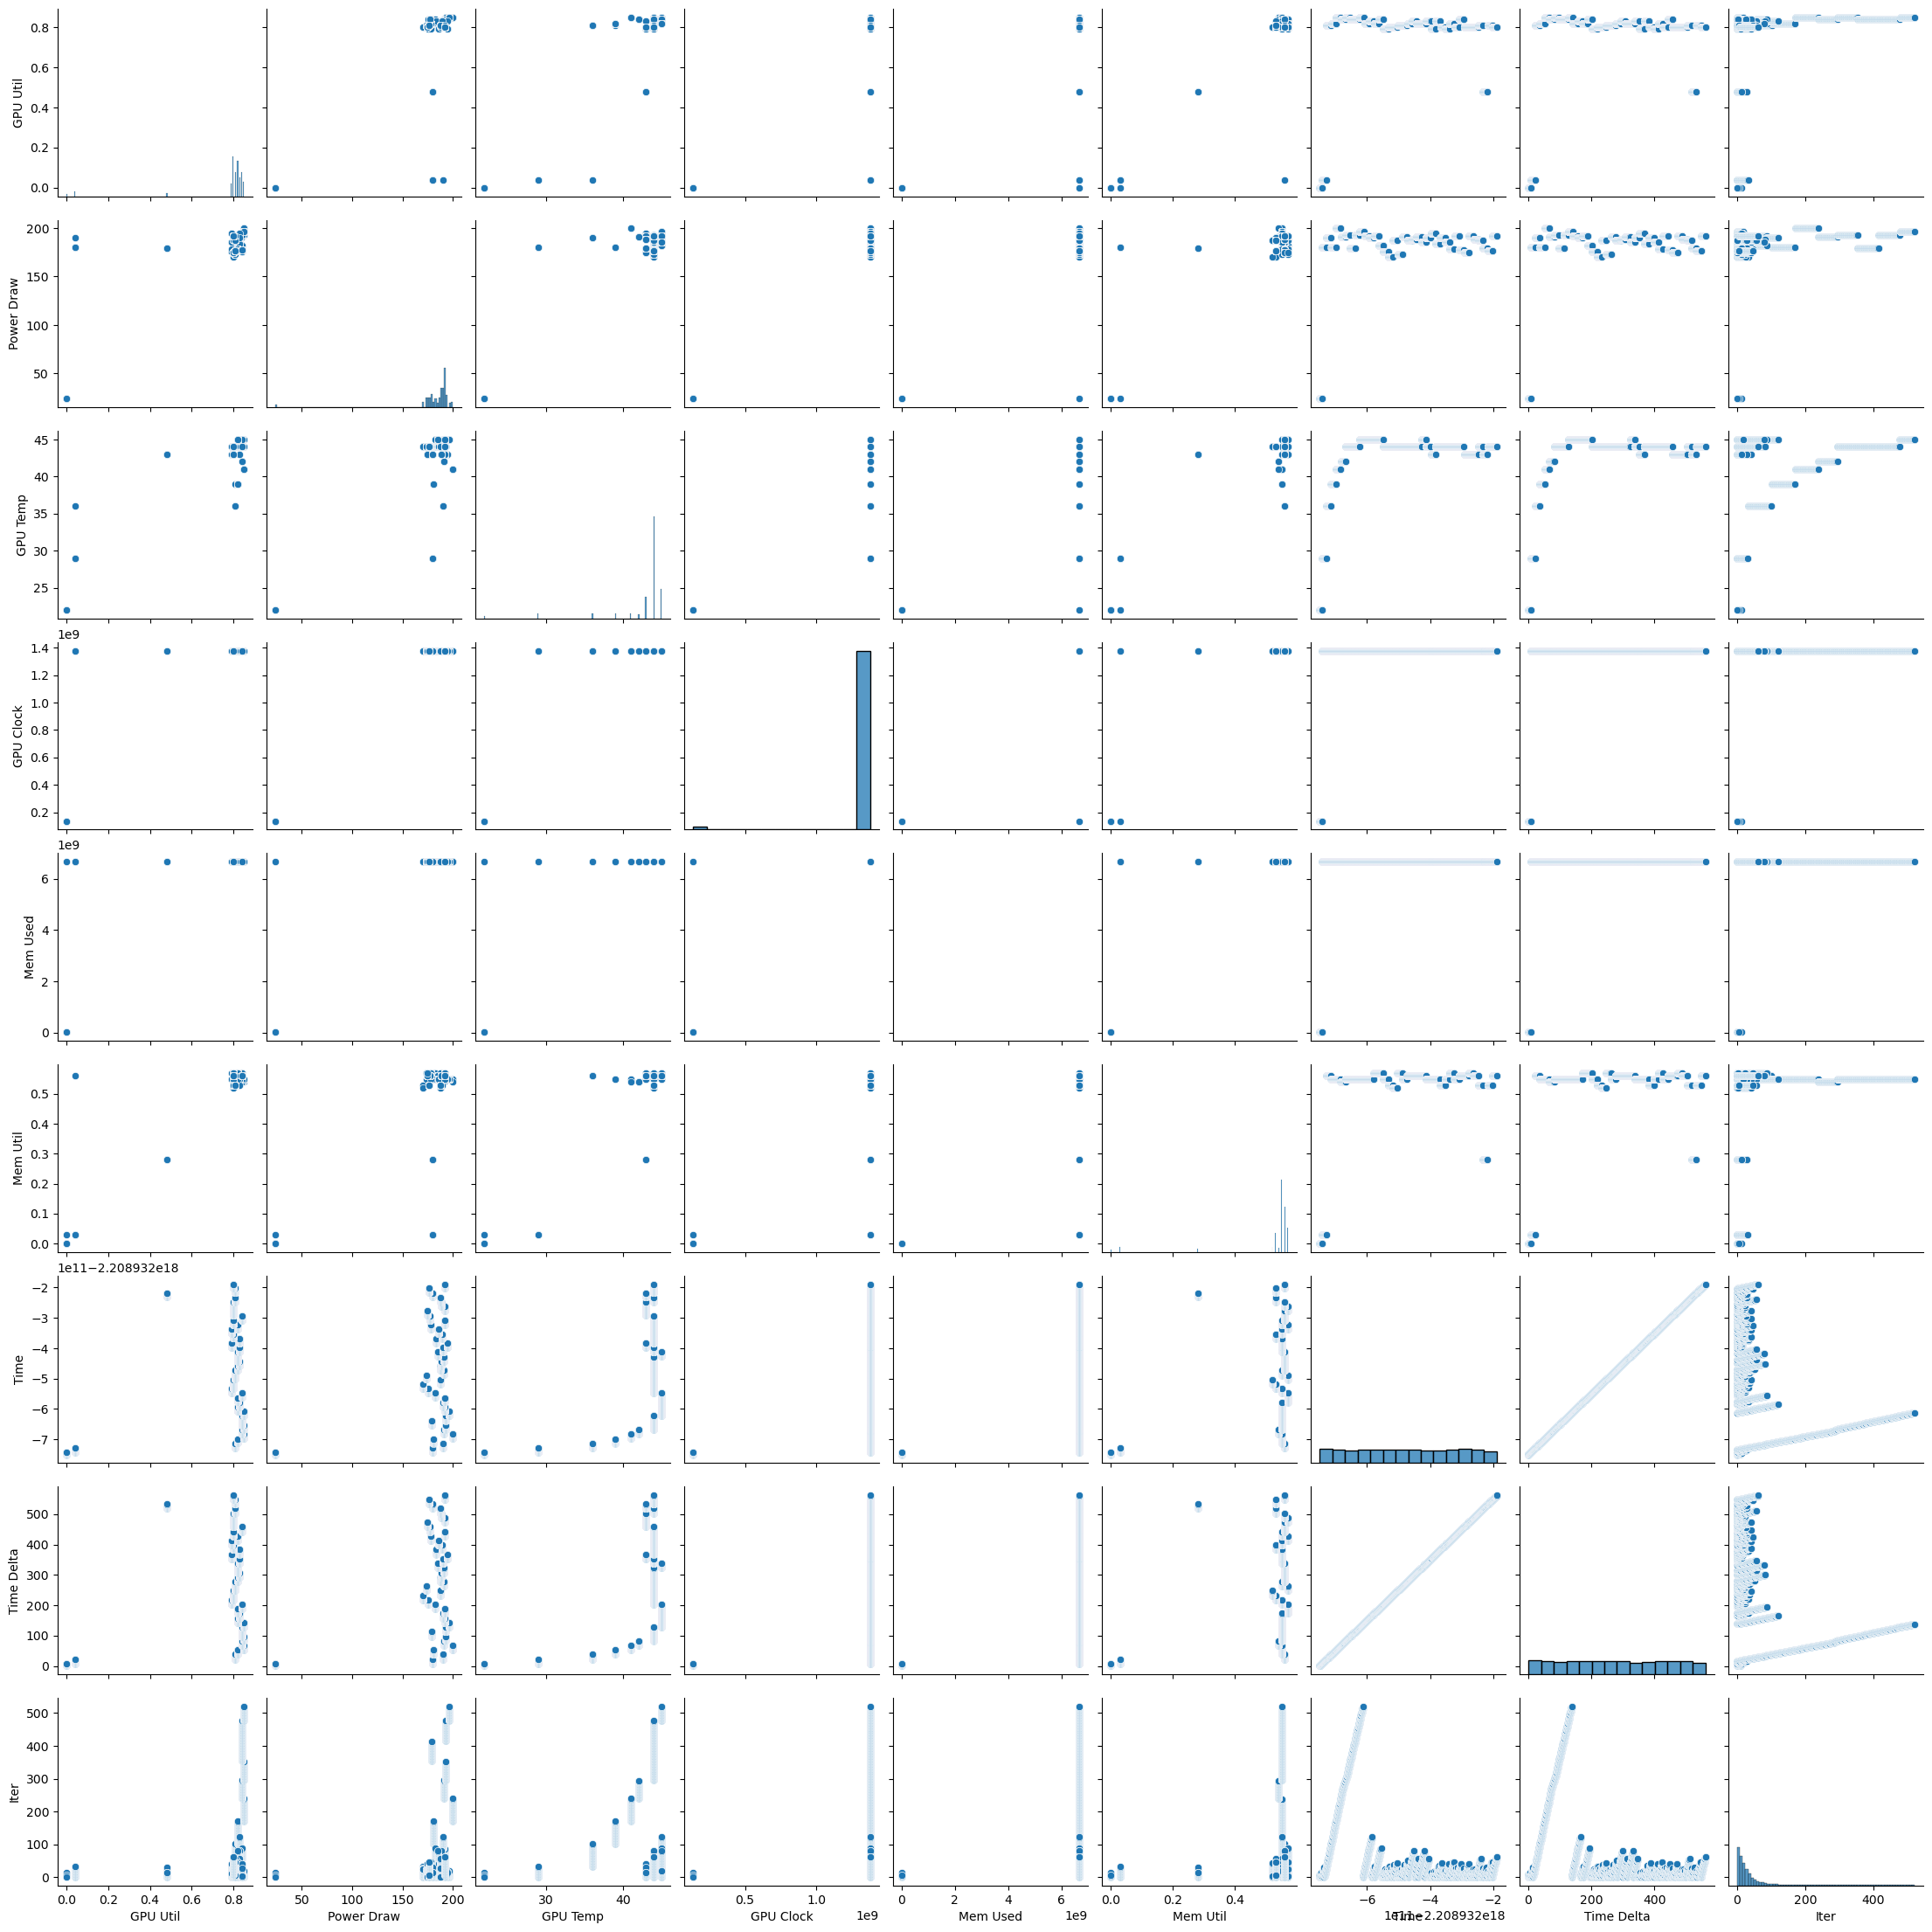

In [168]:
pair_plot = sns.pairplot(live_data, corner=False)

In [169]:
column_names = live_data.columns.tolist()
live_avg = dict(zip(column_names, [list(range(len(reset_iters)))] * len(column_names)))
live_avg = pd.DataFrame(live_avg, dtype=np.float64)

In [170]:
temp_df = dict()
count = 0
for iter in range(1, len(reset_iters)):
    # print(f"Count: {str(count)}")
    start_index = reset_iters[iter-1]
    end_index = reset_iters[iter]-1
    # print(f"Current Slice: {str(start_index)}:{str(end_index)}")
    for col in range(len(column_names)):
        temp_list = live_data.iloc[start_index:end_index,  col].tolist() 
        # print(f"On column: {str(col)} with the average: {str(np.average(temp_list))}")
        live_avg.iloc[count, col] = np.float64(np.average(temp_list))
    count+=1

live_avg = live_avg.copy().iloc[:-1,:]

In [171]:
from sklearn.preprocessing import normalize, StandardScaler

live_avg_norm = normalize(live_avg)
ss = StandardScaler()
live_avg_scaled = ss.fit_transform(live_avg)

In [172]:
live_avg_scaled = pd.DataFrame(data=live_avg_scaled)
live_avg_scaled.columns = live_avg.columns

live_avg_norm = pd.DataFrame(data=live_avg_norm)
live_avg_norm.columns = live_avg.columns

In [173]:
live_avg['Response Time'] = response_time
live_avg['Eval Rate'] = eval_rates[:-1]

In [175]:
live_avg.to_csv("../data/samples/ollama_processed/live_avg.csv", index=False)
live_avg_scaled.to_csv("../data/samples/ollama_processed/live_avg_scaled.csv", index=False)
live_avg_norm.to_csv("../data/samples/ollama_processed/live_avg_norm.csv", index=False)

In [176]:
live_avg

,GPU Util,Power Draw,GPU Temp,GPU Clock,Mem Used,Mem Util,Time,Time Delta,Iter,Response Time,Eval Rate
0,0.000000,23.740000,22.000000,1.350000e+08,9.437184e+06,0.000000,-2.208933e+18,1.916667,6.5,2606602931,92.848743
1,0.000000,23.740000,22.000000,1.350000e+08,9.437184e+06,0.000000,-2.208933e+18,3.666667,2.0,522210414,82.672835
2,0.000000,23.740000,22.000000,1.350000e+08,9.437184e+06,0.000000,-2.208933e+18,5.307692,7.0,2582972253,82.589487
3,0.000000,23.740000,22.000000,1.350000e+08,9.437184e+06,0.000000,-2.208933e+18,7.200000,3.0,955865074,82.795251
4,0.033333,153.831667,27.833333,1.172500e+09,6.665798e+09,0.030000,-2.208933e+18,8.500000,3.5,1145166140,82.972630
...,...,...,...,...,...,...,...,...,...,...,...
64,0.805714,188.162679,43.589286,1.380000e+09,6.669992e+09,0.542321,-2.208932e+18,504.142857,28.5,13239929137,80.305746
65,0.810000,187.830000,44.000000,1.380000e+09,6.669992e+09,0.530000,-2.208932e+18,514.178571,14.5,6724486555,80.335888
66,0.491379,180.018966,43.034483,1.380000e+09,6.669992e+09,0.288621,-2.208932e+18,521.862069,15.0,9312371059,82.007438
67,0.579000,178.675000,43.300000,1.380000e+09,6.669992e+09,0.355000,-2.208932e+18,531.450000,10.5,7641057292,80.087957


In [177]:
live_avg_norm

,GPU Util,Power Draw,GPU Temp,GPU Clock,Mem Used,Mem Util,Time,Time Delta,Iter
0,0.000000e+00,1.074727e-17,9.959561e-18,6.111549e-11,4.272282e-12,0.000000e+00,-1.0,8.676890e-19,2.942598e-18
1,0.000000e+00,1.074727e-17,9.959561e-18,6.111549e-11,4.272282e-12,0.000000e+00,-1.0,1.659927e-18,9.054146e-19
2,0.000000e+00,1.074727e-17,9.959561e-18,6.111549e-11,4.272282e-12,0.000000e+00,-1.0,2.402831e-18,3.168951e-18
3,0.000000e+00,1.074727e-17,9.959561e-18,6.111549e-11,4.272282e-12,0.000000e+00,-1.0,3.259493e-18,1.358122e-18
4,1.509024e-20,6.964072e-17,1.260035e-17,5.307993e-10,3.017655e-09,1.358122e-20,-1.0,3.848012e-18,1.584476e-18
...,...,...,...,...,...,...,...,...,...
64,3.647528e-19,8.518264e-17,1.973319e-17,6.247362e-10,3.019555e-09,2.455129e-19,-1.0,2.282292e-16,1.290216e-17
65,3.666930e-19,8.503203e-17,1.991913e-17,6.247362e-10,3.019555e-09,2.399349e-19,-1.0,2.327725e-16,6.564258e-18
66,2.224511e-19,8.149592e-17,1.948203e-17,6.247362e-10,3.019555e-09,1.306607e-19,-1.0,2.362508e-16,6.790611e-18
67,2.621176e-19,8.088750e-17,1.960223e-17,6.247362e-10,3.019555e-09,1.607111e-19,-1.0,2.405914e-16,4.753428e-18


In [178]:
live_avg_scaled

,GPU Util,Power Draw,GPU Temp,GPU Clock,Mem Used,Mem Util,Time,Time Delta,Iter
0,-3.216034,-3.958002,-3.555203,-4.016504,-4.031128,-3.188809,-2.206597,-2.206601,-0.326180
1,-3.216034,-3.958002,-3.555203,-4.016504,-4.031128,-3.188809,-2.195193,-2.194627,-0.468127
2,-3.216034,-3.958002,-3.555203,-4.016504,-4.031128,-3.188809,-2.183088,-2.183398,-0.310409
3,-3.216034,-3.958002,-3.555203,-4.016504,-4.031128,-3.188809,-2.170561,-2.170449,-0.436584
4,-3.070216,-0.543743,-2.525425,-0.454309,0.245679,-2.996860,-2.162123,-2.161553,-0.420812
...,...,...,...,...,...,...,...,...,...
64,0.308599,0.357275,0.256026,0.258130,0.248374,0.281116,1.229695,1.229990,0.367782
65,0.327347,0.348544,0.328531,0.258130,0.248374,0.202280,1.298972,1.298662,-0.073831
66,-1.066473,0.143543,0.158085,0.258130,0.248374,-1.342133,1.350955,1.351238,-0.058059
67,-0.683173,0.108271,0.204957,0.258130,0.248374,-0.917419,1.415778,1.416846,-0.200006
